# ARIMA for Predictive Maintenance — NASA IMS Bearing Dataset

**Objective:** demonstrate that ARIMA is effective for forecasting a predictive-maintenance
time series by forecasting a bearing **health indicator** (RMS vibration) rather than the
failure event itself, and showing the forecast accurately captures the degradation trend
before failure.

The pipeline follows these stages, each implemented as **one function per cell**:

1. Load raw vibration files (or generate a synthetic run-to-failure signal if no dataset is available)
1.5. Visualize the raw high-frequency vibration signal for a single file
2. Extract the RMS health indicator from each file → build a univariate time series
3. Visualize the time series
4. Check stationarity (ADF test) and difference if needed
4.5. Visualize the differenced RMS series
5. Chronological train/test split (80/20)
6. Inspect ACF/PACF and select ARIMA(p,d,q) order
7. Train the ARIMA model
8. Forecast the test horizon
9. Plot actual vs. predicted
10. Evaluate performance (MAE, RMSE, MAPE)
11. Residual diagnostics (white noise check, Ljung-Box)
12. Predictive-maintenance threshold crossing
13. Compare ARIMA against naive / moving-average / SES baselines
14. Run the full pipeline end-to-end

---
### About the data
This notebook is written against the **NASA IMS Bearing Dataset** (Test 2, Bearing 1),
where each file contains 20,480 vibration samples collected every 10 minutes.

Download it from the NASA Prognostics Data Repository / IMS Bearing Data page, unzip it,
and point `DATA_DIR` (below) at the folder containing the `2nd_test` files.

If `DATA_DIR` does not exist, the loader will automatically fall back to a **synthetic**
bearing-degradation signal (stable → gradual rise → sharp rise before failure) so that the
whole pipeline can still be run and demonstrated end-to-end without the real dataset.

## 0. Imports & configuration

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from itertools import product

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (11, 4)

In [2]:
# ---- Configuration -------------------------------------------------------
# Point this at the folder containing the NASA IMS 'Test 2' bearing files.
# Each file in that folder is a whitespace-delimited text file with one column
# per bearing channel and 20,480 rows of raw vibration samples.
DATA_DIR = 'data/2nd_test'

# Which column (0-indexed) in each file corresponds to the bearing of interest
BEARING_COLUMN = 0

# Sampling interval between consecutive files, in minutes
SAMPLING_INTERVAL_MIN = 10

# Train/test split fraction (chronological, not random)
TRAIN_FRACTION = 0.8

# RMS threshold above which the bearing is considered unhealthy
MAINTENANCE_THRESHOLD = 2.0

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Step 1 — Load raw vibration files

Reads every vibration file in `DATA_DIR` in chronological order. Each file is one
10-minute snapshot containing 20,480 raw vibration samples for the selected bearing/channel.

If `DATA_DIR` isn't found, a synthetic run-to-failure vibration dataset is generated instead,
so the rest of the pipeline can still be demonstrated.

In [3]:
def load_bearing_data(data_dir=DATA_DIR, bearing_column=BEARING_COLUMN,
                       n_synthetic_files=900, samples_per_file=20480):
    """
    Load raw vibration snapshots for a single bearing channel.

    Returns
    -------
    list[np.ndarray]
        One array of raw vibration samples per file, in chronological order.
    """
    if os.path.isdir(data_dir) and len(os.listdir(data_dir)) > 0:
        file_paths = sorted(glob.glob(os.path.join(data_dir, '*')))
        raw_signals = []
        for path in file_paths:
            data = np.loadtxt(path)
            column = data[:, bearing_column] if data.ndim > 1 else data
            raw_signals.append(column)
        print(f'Loaded {len(raw_signals)} real vibration files from {data_dir}')
        return raw_signals

    # ---- Synthetic fallback ------------------------------------------------
    print(f"'{data_dir}' not found — generating a synthetic run-to-failure signal "
          f"({n_synthetic_files} files) for demonstration purposes.")
    raw_signals = []
    for i in range(n_synthetic_files):
        frac = i / n_synthetic_files
        # amplitude stays low, then degrades, then spikes sharply near failure
        base_amplitude = 0.15 + 0.05 * frac
        if frac > 0.75:
            degradation = 2.5 * (frac - 0.75) ** 3
        else:
            degradation = 0.0
        noise = np.random.normal(0, base_amplitude + degradation, samples_per_file)
        signal = noise + 0.02 * np.sin(np.linspace(0, 40 * np.pi, samples_per_file))
        raw_signals.append(signal)
    return raw_signals

## Step 1.5 — Visualize raw vibration signal

Plots the raw high-frequency vibration signal snapshot (e.g. 20,480 samples at 20 kHz) from a single selected file to understand the raw sensor inputs before extracting the RMS feature.

In [4]:
def visualize_raw_signal(raw_signals, file_index=0, sample_rate=20000):
    """
    Plot the raw high-frequency vibration signal snapshot from a single file.
    """
    signal = raw_signals[file_index]
    time = np.linspace(0, len(signal) / sample_rate, len(signal))
    
    plt.figure()
    plt.plot(time, signal, color='darkorange', linewidth=0.5)
    plt.title(f'Raw Vibration Signal Snapshot (File Index: {file_index})')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    plt.show()

## Step 2 — Extract the RMS health indicator

Collapses each raw vibration snapshot into a single Root Mean Square (RMS) value,
producing one univariate time series that becomes the ARIMA input.

In [5]:
def extract_rms_features(raw_signals, sampling_interval_min=SAMPLING_INTERVAL_MIN,
                          start_time='2004-01-01'):
    """
    Compute the RMS of each raw vibration snapshot and assemble a time-indexed
    pandas Series.

    Parameters
    ----------
    raw_signals : list[np.ndarray]
        Output of load_bearing_data().

    Returns
    -------
    pd.Series
        RMS vibration indexed by timestamp, one value per file.
    """
    rms_values = [np.sqrt(np.mean(np.square(signal))) for signal in raw_signals]
    timestamps = pd.date_range(start=start_time, periods=len(rms_values),
                                freq=f'{sampling_interval_min}min')
    series = pd.Series(rms_values, index=timestamps, name='RMS')
    return series

## Step 3 — Visualize the RMS time series

In [6]:
def visualize_time_series(series, title='Bearing RMS Vibration Over Time'):
    """Plot the RMS health-indicator time series."""
    plt.figure()
    plt.plot(series.index, series.values, color='steelblue', linewidth=1)
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('RMS')
    plt.tight_layout()
    plt.show()

## Step 4 — Check stationarity (ADF test) and difference if needed

Runs the Augmented Dickey-Fuller test. If the series is not stationary (p-value > 0.05),
it is differenced and re-tested, up to `max_diff` times.

In [7]:
def check_stationarity(series, alpha=0.05, verbose=True):
    """
    Run the Augmented Dickey-Fuller test on a series.

    Returns
    -------
    dict with keys: adf_stat, p_value, is_stationary
    """
    result = adfuller(series.dropna())
    adf_stat, p_value = result[0], result[1]
    is_stationary = p_value < alpha
    if verbose:
        print(f'ADF statistic: {adf_stat:.4f}')
        print(f'p-value:       {p_value:.4f}')
        print('=> Stationary' if is_stationary else '=> Not stationary')
    return {'adf_stat': adf_stat, 'p_value': p_value, 'is_stationary': is_stationary}


def difference_until_stationary(series, alpha=0.05, max_diff=3):
    """
    Repeatedly first-difference `series` until the ADF test says it's stationary
    (or max_diff is reached).

    Returns
    -------
    (pd.Series, int)
        The (possibly differenced) series, and the number of differences applied (d).
    """
    current = series.copy()
    d = 0
    while d < max_diff:
        stat = check_stationarity(current, alpha=alpha, verbose=False)
        print(f'd={d}: ADF p-value = {stat["p_value"]:.4f} '
              f'({"stationary" if stat["is_stationary"] else "not stationary"})')
        if stat['is_stationary']:
            break
        current = current.diff().dropna()
        d += 1
    return current, d

## Step 4.5 — Visualize the differenced RMS series

Plots the RMS time series after applying the differencing order $d$ required to make it stationary.

In [8]:
def visualize_differenced_series(differenced_series, d):
    """
    Plot the differenced RMS time series.
    """
    if d == 0:
        print("Series is already stationary (d=0); no differencing applied.")
        return
    plt.figure()
    plt.plot(differenced_series.index, differenced_series.values, color='forestgreen', linewidth=1)
    plt.title(f'Bearing RMS Vibration (Differenced, d={d})')
    plt.xlabel('Time')
    plt.ylabel(f'Differenced RMS (d={d})')
    plt.tight_layout()
    plt.show()

## Step 5 — Chronological train/test split

Splits the series by time order (never randomly) so that the test set always comes
after the training set, as required for forecasting evaluation.

In [9]:
def train_test_split_series(series, train_fraction=TRAIN_FRACTION):
    """
    Chronologically split a time series into train/test sets.

    Returns
    -------
    (pd.Series, pd.Series)
        train, test
    """
    split_idx = int(len(series) * train_fraction)
    train = series.iloc[:split_idx]
    test = series.iloc[split_idx:]
    print(f'Train: {len(train)} points | Test: {len(test)} points')
    return train, test

## Step 6 — Inspect ACF/PACF and select ARIMA(p, d, q)

Plots the ACF (to estimate q) and PACF (to estimate p) of the (differenced) training series,
then performs a small grid search over candidate (p, d, q) combinations, selecting the
model with the lowest AIC — a manual stand-in for `auto_arima`.

In [10]:
def plot_acf_pacf(series, lags=40):
    """Plot ACF and PACF of a (typically differenced) series."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(series.dropna(), lags=lags, ax=axes[0])
    axes[0].set_title('ACF')
    axes[0].set_xlabel('Lag')
    axes[0].set_ylabel('Autocorrelation')
    plot_pacf(series.dropna(), lags=lags, ax=axes[1], method='ywm')
    axes[1].set_title('PACF')
    axes[1].set_xlabel('Lag')
    axes[1].set_ylabel('Partial Autocorrelation')
    plt.tight_layout()
    plt.show()


def select_arima_order(train, d, p_range=range(0, 4), q_range=range(0, 4)):
    """
    Grid-search over (p, q) for a fixed differencing order d, choosing the
    combination with the lowest AIC. This is a manual stand-in for auto_arima.

    Returns
    -------
    (int, int, int)
        Best (p, d, q) order found.
    """
    best_aic = np.inf
    best_order = None
    for p, q in product(p_range, q_range):
        if p == 0 and q == 0:
            continue
        try:
            model = ARIMA(train, order=(p, d, q))
            fitted = model.fit()
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = (p, d, q)
        except Exception:
            continue
    print(f'Best order found: ARIMA{best_order} (AIC={best_aic:.2f})')
    return best_order

## Step 7 — Train the ARIMA model

In [11]:
def train_arima_model(train, order):
    """Fit an ARIMA(p, d, q) model on the training series."""
    model = ARIMA(train, order=order)
    fitted_model = model.fit()
    print(fitted_model.summary())
    return fitted_model

## Step 8 — Forecast the test horizon

In [12]:
def forecast_arima(fitted_model, steps):
    """
    Forecast `steps` points ahead.

    Returns
    -------
    pd.Series indexed the same way as the forecast horizon.
    """
    forecast_result = fitted_model.get_forecast(steps=steps)
    forecast_mean = forecast_result.predicted_mean
    conf_int = forecast_result.conf_int()
    return forecast_mean, conf_int

## Step 9 — Plot actual vs. predicted

In [13]:
def plot_forecast_vs_actual(train, test, forecast_mean, conf_int=None,
                             title='ARIMA Forecast vs. Actual RMS'):
    """Plot training data, actual test data, and the ARIMA forecast together."""
    plt.figure()
    plt.plot(train.index, train.values, label='Train', color='gray', alpha=0.6)
    plt.plot(test.index, test.values, label='Actual (test)', color='steelblue')
    plt.plot(forecast_mean.index, forecast_mean.values, label='ARIMA Forecast',
             color='crimson', linestyle='--')
    if conf_int is not None:
        plt.fill_between(forecast_mean.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                          color='crimson', alpha=0.15, label='95% CI')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('RMS')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Step 10 — Evaluate performance (MAE, RMSE, MAPE)

In [14]:
def evaluate_forecast(actual, predicted, label='ARIMA'):
    """
    Compute MAE, RMSE, and MAPE between actual and predicted series.

    Returns
    -------
    dict with keys: model, mae, rmse, mape
    """
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f'{label:15s} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.2f}%')
    return {'model': label, 'mae': mae, 'rmse': rmse, 'mape': mape}

## Step 11 — Residual diagnostics

Checks that residuals are approximately zero-mean, resemble white noise, and show no
significant remaining autocorrelation (Ljung-Box test) — validating the ARIMA model assumptions.

In [15]:
def residual_diagnostics(fitted_model, lags=20):
    """
    Plot residuals and run the Ljung-Box test for remaining autocorrelation.

    Returns
    -------
    pd.DataFrame — Ljung-Box test results.
    """
    residuals = fitted_model.resid
    print(f'Residual mean: {residuals.mean():.5f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(residuals)
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_title('Residuals over time')
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('Residual')
    plot_acf(residuals.dropna(), lags=lags, ax=axes[1])
    axes[1].set_title('Residual ACF')
    axes[1].set_xlabel('Lag')
    axes[1].set_ylabel('Autocorrelation')
    plt.tight_layout()
    plt.show()

    lb_result = acorr_ljungbox(residuals.dropna(), lags=[lags], return_df=True)
    print(lb_result)
    p_value = lb_result['lb_pvalue'].iloc[0]
    print('=> Residuals resemble white noise (good fit)' if p_value > 0.05
          else '=> Significant autocorrelation remains (model may be underspecified)')
    return lb_result

## Step 12 — Predictive maintenance: threshold crossing

Determines whether/when the forecast RMS is expected to cross the maintenance threshold,
demonstrating maintenance being scheduled *before* the actual failure.

In [16]:
def predictive_maintenance_alert(forecast_mean, threshold=MAINTENANCE_THRESHOLD):
    """
    Determine the first forecasted timestamp at which RMS is predicted to exceed
    the maintenance threshold.

    Returns
    -------
    pd.Timestamp or None
    """
    exceeding = forecast_mean[forecast_mean > threshold]
    if len(exceeding) == 0:
        print(f'No threshold ({threshold}) crossing predicted within the forecast horizon.')
        return None
    alert_time = exceeding.index[0]
    print(f'Bearing RMS predicted to exceed {threshold} at {alert_time} '
          f'-> schedule maintenance before this time.')
    return alert_time

## Step 13 — Compare ARIMA against simple baselines

Naive forecast, moving average, and simple exponential smoothing (SES), so ARIMA's
accuracy can be judged relative to simpler alternatives rather than in isolation.

In [17]:
def baseline_naive_forecast(train, steps):
    """Naive forecast: repeat the last observed training value."""
    last_value = train.iloc[-1]
    return pd.Series([last_value] * steps)


def baseline_moving_average_forecast(train, steps, window=10):
    """Moving-average forecast: repeat the mean of the last `window` training points."""
    avg = train.iloc[-window:].mean()
    return pd.Series([avg] * steps)


def baseline_ses_forecast(train, steps, alpha=0.3):
    """Simple exponential smoothing forecast, repeated across the horizon."""
    level = train.iloc[0]
    for value in train.iloc[1:]:
        level = alpha * value + (1 - alpha) * level
    return pd.Series([level] * steps)


def compare_models(test, forecasts):
    """
    Evaluate several forecasts against the same actual test series.

    Parameters
    ----------
    forecasts : dict[str, array-like]
        Mapping of model name -> forecast values (same length as `test`).

    Returns
    -------
    pd.DataFrame sorted by RMSE ascending.
    """
    rows = [evaluate_forecast(test.values, values, label=name)
            for name, values in forecasts.items()]
    comparison = pd.DataFrame(rows).sort_values('rmse').reset_index(drop=True)
    return comparison

## Step 14 — Run the full pipeline end-to-end

Wires all the functions above together into a single pipeline call, then executes it.

In [18]:
def run_arima_pipeline(data_dir=DATA_DIR):
    # 1-2: load + extract feature
    raw_signals = load_bearing_data(data_dir)
    
    # 1.5: visualize raw signal
    print('\n--- Visualizing Raw Signal (First Snapshot) ---')
    visualize_raw_signal(raw_signals)
    rms_series = extract_rms_features(raw_signals)

    # 3: visualize
    visualize_time_series(rms_series)

    # 4: stationarity + differencing
    print('\n--- Stationarity check (levels) ---')
    check_stationarity(rms_series)
    print('\n--- Differencing until stationary ---')
    differenced_series, d = difference_until_stationary(rms_series)
    
    # 4.5: plot differenced series
    print('\n--- Visualizing Differenced Series ---')
    visualize_differenced_series(differenced_series, d)

    # 5: train/test split (on the ORIGINAL series; differencing order d is passed to ARIMA)
    train, test = train_test_split_series(rms_series)

    # 6: ACF/PACF + order selection
    train_diff = train.diff(d).dropna() if d > 0 else train
    print('\n--- ACF / PACF of (differenced) training series ---')
    plot_acf_pacf(train_diff)
    order = select_arima_order(train, d=d)

    # 7: train
    print('\n--- Training ARIMA model ---')
    fitted_model = train_arima_model(train, order)

    # 8: forecast
    forecast_mean, conf_int = forecast_arima(fitted_model, steps=len(test))
    forecast_mean.index = test.index
    conf_int.index = test.index

    # 9: plot
    plot_forecast_vs_actual(train, test, forecast_mean, conf_int)

    # 10: evaluate
    print('\n--- Forecast accuracy ---')
    arima_metrics = evaluate_forecast(test.values, forecast_mean.values, label='ARIMA')

    # 11: residual diagnostics
    print('\n--- Residual diagnostics ---')
    residual_diagnostics(fitted_model)

    # 12: predictive maintenance
    print('\n--- Predictive maintenance threshold check ---')
    predictive_maintenance_alert(forecast_mean)

    # 13: baselines
    print('\n--- Baseline comparison ---')
    forecasts = {
        'ARIMA': forecast_mean.values,
        'Naive': baseline_naive_forecast(train, len(test)).values,
        'Moving Average': baseline_moving_average_forecast(train, len(test)).values,
        'SES': baseline_ses_forecast(train, len(test)).values,
    }
    comparison = compare_models(test, forecasts)
    display(comparison)

    return {
        'series': rms_series,
        'train': train,
        'test': test,
        'order': order,
        'model': fitted_model,
        'forecast': forecast_mean,
        'metrics': arima_metrics,
        'comparison': comparison,
    }

Loaded 984 real vibration files from data/2nd_test

--- Visualizing Raw Signal (First Snapshot) ---


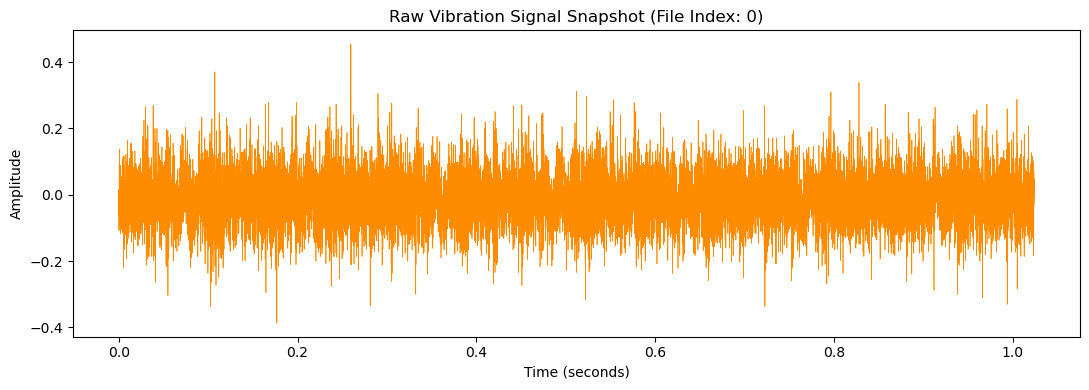

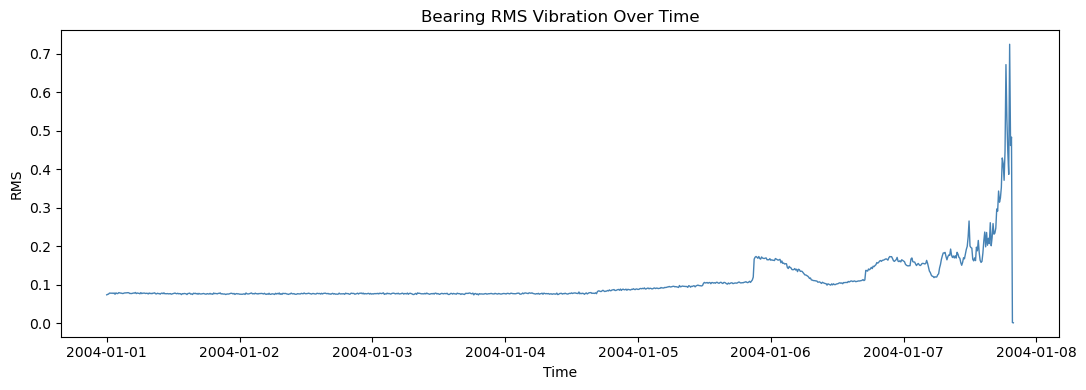


--- Stationarity check (levels) ---
ADF statistic: 0.3653
p-value:       0.9802
=> Not stationary

--- Differencing until stationary ---
d=0: ADF p-value = 0.9802 (not stationary)
d=1: ADF p-value = 0.0000 (stationary)

--- Visualizing Differenced Series ---


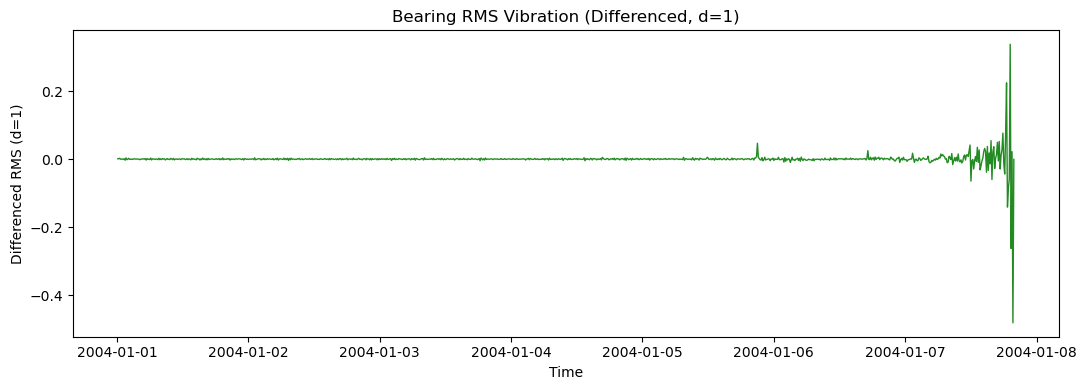

Train: 787 points | Test: 197 points

--- ACF / PACF of (differenced) training series ---


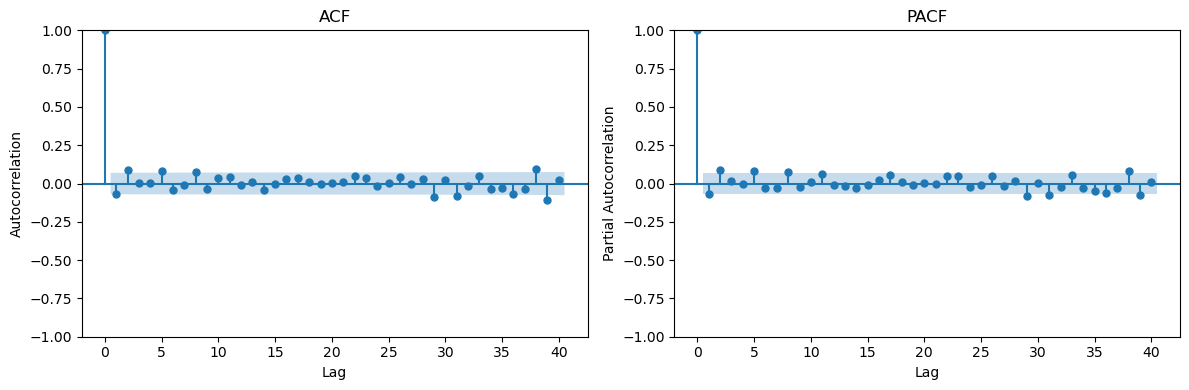

Best order found: ARIMA(3, 1, 3) (AIC=-7262.81)

--- Training ARIMA model ---
                               SARIMAX Results                                
Dep. Variable:                    RMS   No. Observations:                  787
Model:                 ARIMA(3, 1, 3)   Log Likelihood                3638.404
Date:                Mon, 03 Aug 2026   AIC                          -7262.807
Time:                        18:54:55   BIC                          -7230.139
Sample:                    01-01-2004   HQIC                         -7250.247
                         - 01-06-2004                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2504      0.229     -1.095      0.273      -0.698       0.198
ar.L2          0.1556      0.253      0.616      0.53

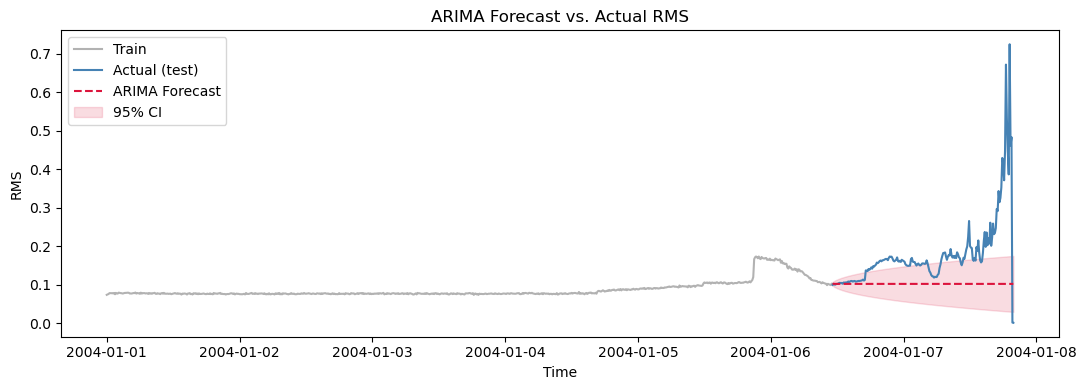


--- Forecast accuracy ---
ARIMA           | MAE: 0.0778 | RMSE: 0.1195 | MAPE: 92.12%

--- Residual diagnostics ---
Residual mean: 0.00013


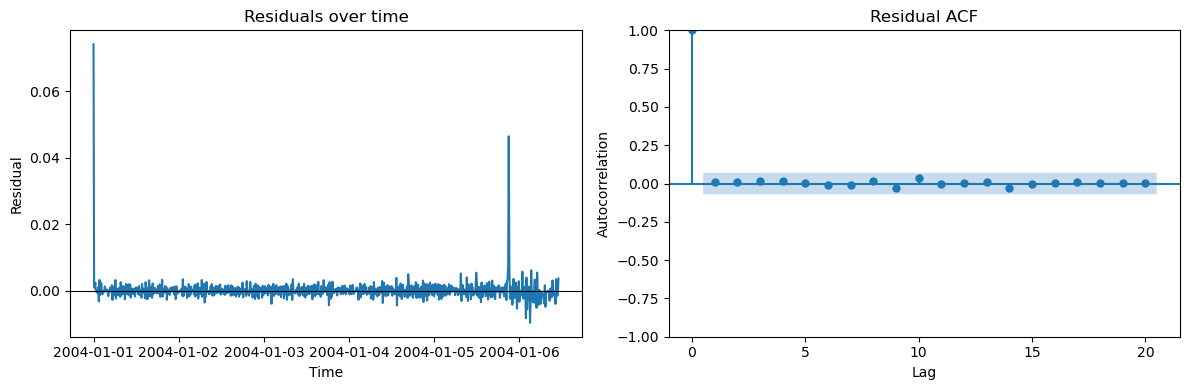

     lb_stat  lb_pvalue
20  3.366225   0.999989
=> Residuals resemble white noise (good fit)

--- Predictive maintenance threshold check ---
No threshold (2.0) crossing predicted within the forecast horizon.

--- Baseline comparison ---
ARIMA           | MAE: 0.0778 | RMSE: 0.1195 | MAPE: 92.12%
Naive           | MAE: 0.0778 | RMSE: 0.1194 | MAPE: 92.12%
Moving Average  | MAE: 0.0782 | RMSE: 0.1197 | MAPE: 92.13%
SES             | MAE: 0.0788 | RMSE: 0.1201 | MAPE: 92.14%


,model,mae,rmse,mape
0,Naive,0.077781,0.119442,92.118897
1,ARIMA,0.077816,0.119467,92.117927
2,Moving Average,0.078151,0.119692,92.125766
3,SES,0.078764,0.120104,92.142602


In [19]:
results = run_arima_pipeline(DATA_DIR)

---
### Conclusion
If the ARIMA forecast tracks the actual RMS degradation trend closely (Step 9), achieves
lower MAE/RMSE/MAPE than the naive, moving-average, and SES baselines (Step 13), and its
residuals resemble white noise (Step 11), this constitutes quantitative and visual evidence
that **ARIMA is effective for forecasting this predictive-maintenance time series** —
without ARIMA ever being asked to directly classify or predict the failure event itself.